In [56]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs, make_swiss_roll, make_moons
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn
from scipy.spatial.distance import cdist
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from ott.tools.sinkhorn_divergence import sinkhorn_divergence
from ott.geometry.pointcloud import PointCloud

from src.utils import chamfer_distance

## 1) Test on Gaussian blobs data

### a) Generating data

In [58]:
# Generate 2 Gaussian blobs
X, labels_X = make_blobs(n_samples=100, centers=[[0, 0]], cluster_std=1.0, random_state=42)
Y, labels_Y = make_blobs(n_samples=100, centers=[[0, 10], [0, -10]], cluster_std=1.0, random_state=24)

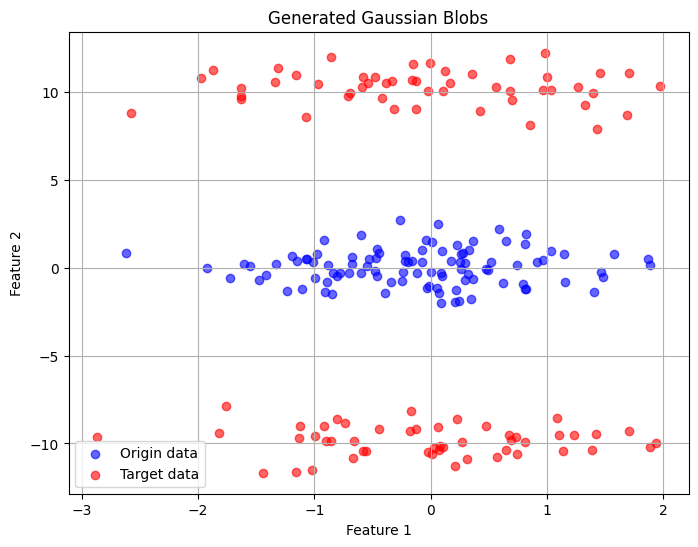

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Origin data', alpha=0.6)
plt.scatter(Y[:, 0], Y[:, 1], c='red', label='Target data', alpha=0.6)

plt.legend()
plt.title('Generated Gaussian Blobs')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### b) Testing the model

CPU times: user 32 μs, sys: 2 μs, total: 34 μs
Wall time: 68.7 μs

Entropic OT plan (reg=0.1)
Wasserstein distance (reg=0.1): 0.05
Chamfer distance (reg=0.1): 0.19
Dual distance (reg=0.1): 87.36


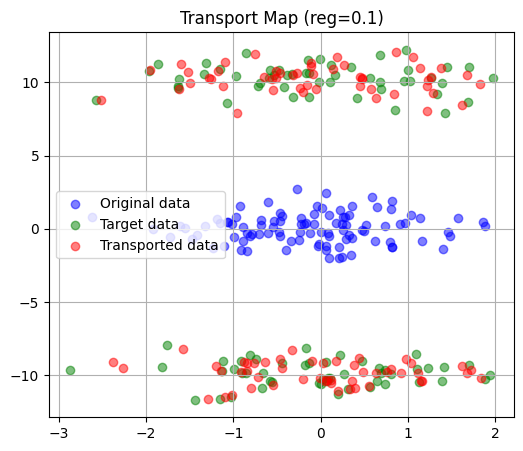

CPU times: user 13 μs, sys: 1e+03 ns, total: 14 μs
Wall time: 29.6 μs

Entropic OT plan (reg=1.0)
Wasserstein distance (reg=1.0): 0.78
Chamfer distance (reg=1.0): 0.35
Dual distance (reg=1.0): 97.29


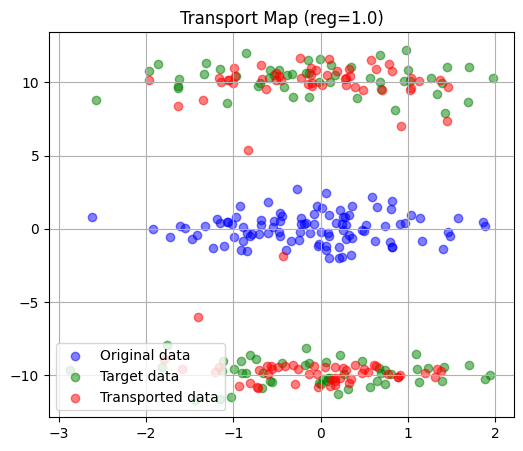

CPU times: user 31 μs, sys: 3 μs, total: 34 μs
Wall time: 69.1 μs

Entropic OT plan (reg=10.0)
Wasserstein distance (reg=10.0): 10.43
Chamfer distance (reg=10.0): 1.52
Dual distance (reg=10.0): 186.06


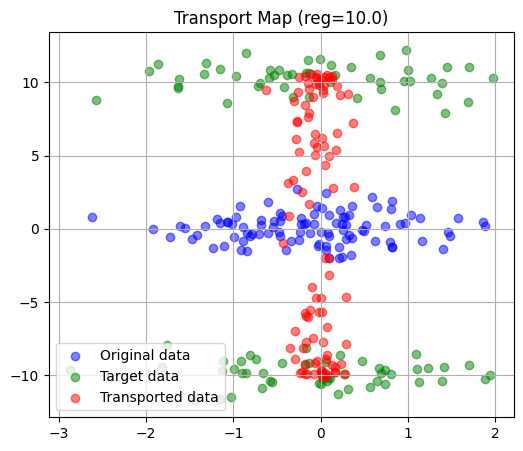

In [61]:
reg_list = [0.1, 1.0, 10.0]

for reg in reg_list:
    %time
    print(f"\nEntropic OT plan (reg={reg})")

    # Step 1: Define geometry
    geom = pointcloud.PointCloud(X, Y, epsilon=reg)

    # Step 2: Define the problem
    problem = linear_problem.LinearProblem(geom)

    # Step 3: Solve with Sinkhorn
    solver = sinkhorn.Sinkhorn()
    out = solver(problem)

    # Step 4: Transport using dual potentials
    entropic_map = out.to_dual_potentials()
    transported_X = entropic_map.transport(X)

    # Step 5: Compute distances
    ch_dist = chamfer_distance(transported_X, Y)
    dual_dist = entropic_map.distance(X, Y)
    wass_dist = sinkhorn_divergence(PointCloud, transported_X, Y, epsilon=0.1, 
                                    a=jnp.ones(len(transported_X)) / len(transported_X), b=jnp.ones(len(Y)) / len(Y))[0]
    print(f"Wasserstein distance (reg={reg}): {wass_dist:.2f}")
    print(f"Chamfer distance (reg={reg}): {ch_dist:.2f}")
    print(f"Dual distance (reg={reg}): {dual_dist:.2f}")

    # Step 7: Visualization
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c='blue', label='Original data', alpha=0.5)
    plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target data', alpha=0.5)
    plt.scatter(transported_X[:, 0], transported_X[:, 1], c='red', label='Transported data', alpha=0.5)
    plt.title(f"Transport Map (reg={reg})")
    plt.legend()
    plt.grid(True)
    plt.show()

## 2) Test on moon data 

### a) Generating data

In [62]:
X, labels_X = make_moons(n_samples=200, noise=0.1, random_state=42)
Y, labels_Y = make_moons(n_samples=200, noise=0.1, random_state=42)
offset = np.array([3, 3])
Y = Y + offset

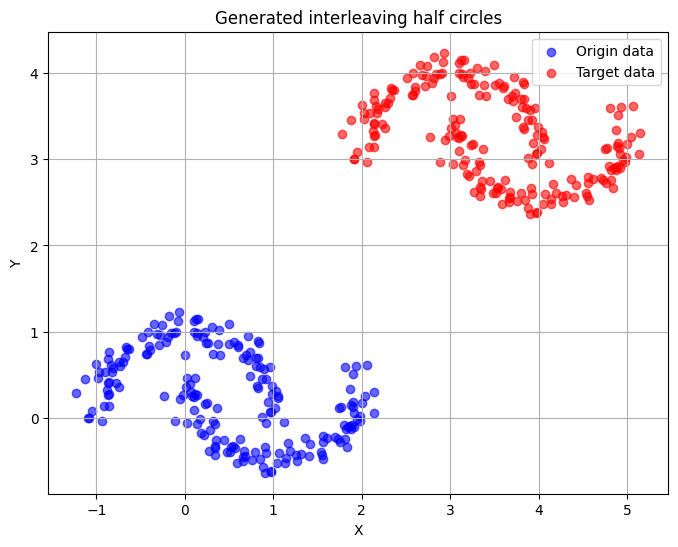

In [63]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Origin data', alpha=0.6)
plt.scatter(Y[:, 0], Y[:, 1], c='red', label='Target data', alpha=0.6)

plt.legend()
plt.title('Generated interleaving half circles')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

### b) Testing the model

CPU times: user 32 μs, sys: 2 μs, total: 34 μs
Wall time: 73 μs

Entropic OT plan (reg=0.1)
Wasserstein distance (reg=0.1): 0.00
Chamfer distance (reg=0.1): 0.04
Dual distance (reg=0.1): 19.32


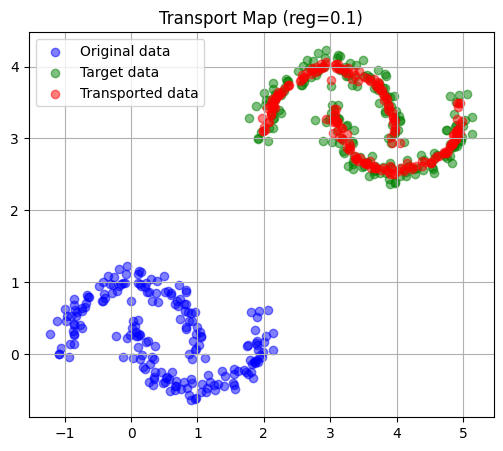

CPU times: user 45 μs, sys: 3 μs, total: 48 μs
Wall time: 88 μs

Entropic OT plan (reg=1.0)
Wasserstein distance (reg=1.0): 0.12
Chamfer distance (reg=1.0): 0.14
Dual distance (reg=1.0): 29.70


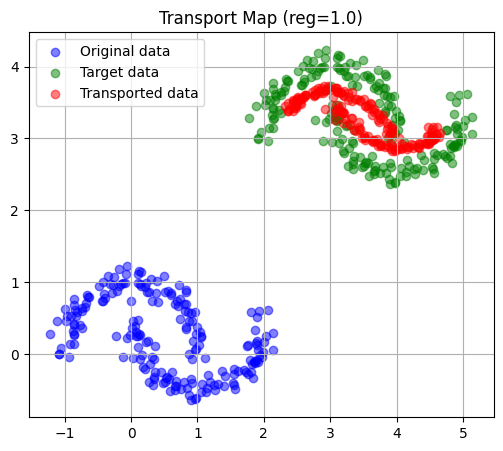

CPU times: user 45 μs, sys: 3 μs, total: 48 μs
Wall time: 85.6 μs

Entropic OT plan (reg=10.0)
Wasserstein distance (reg=10.0): 0.72
Chamfer distance (reg=10.0): 0.20
Dual distance (reg=10.0): 125.87


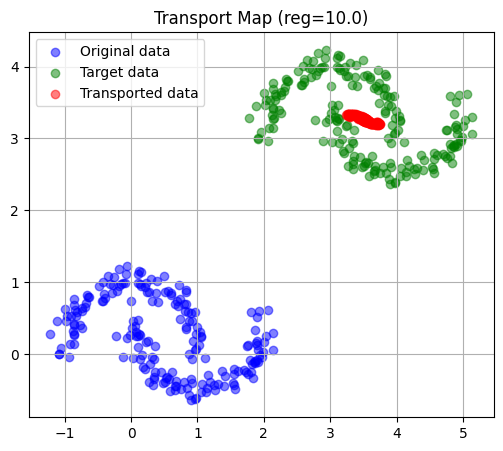

In [64]:
reg_list = [0.1, 1.0, 10.0]

for reg in reg_list:
    %time
    print(f"\nEntropic OT plan (reg={reg})")

    # Step 1: Define geometry
    geom = pointcloud.PointCloud(X, Y, epsilon=reg)

    # Step 2: Define the problem
    problem = linear_problem.LinearProblem(geom)

    # Step 3: Solve with Sinkhorn
    solver = sinkhorn.Sinkhorn()
    out = solver(problem)

    # Step 4: Transport using dual potentials
    entropic_map = out.to_dual_potentials()
    transported_X = entropic_map.transport(X)

    # Step 5: Compute distances
    ch_dist = chamfer_distance(transported_X, Y)
    dual_dist = entropic_map.distance(X, Y)
    wass_dist = sinkhorn_divergence(PointCloud, transported_X, Y, epsilon=0.1, 
                                    a=jnp.ones(len(transported_X)) / len(transported_X), b=jnp.ones(len(Y)) / len(Y))[0]
    print(f"Wasserstein distance (reg={reg}): {wass_dist:.2f}")
    print(f"Chamfer distance (reg={reg}): {ch_dist:.2f}")
    print(f"Dual distance (reg={reg}): {dual_dist:.2f}")
    
    # Step 7: Visualization
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c='blue', label='Original data', alpha=0.5)
    plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target data', alpha=0.5)
    plt.scatter(transported_X[:, 0], transported_X[:, 1], c='red', label='Transported data', alpha=0.5)
    plt.title(f"Transport Map (reg={reg})")
    plt.legend()
    plt.grid(True)
    plt.show()

## 3) Test on swiss roll data

### a) Generating data

In [65]:
X, t_x = make_swiss_roll(n_samples=200, noise=1.5, random_state=42)
Y, t_y = make_swiss_roll(n_samples=200, noise=0, random_state=42)

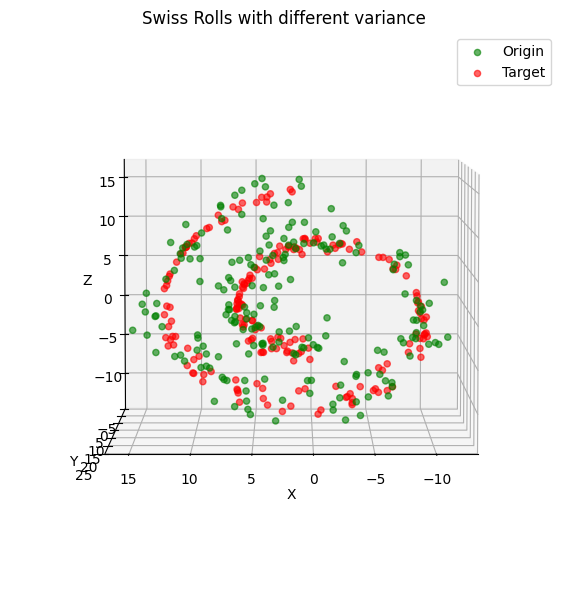

In [66]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot X
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='green', label='Origin', alpha=0.6)

# Plot Y
ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], c='red', label='Target', alpha=0.6)

# Customize plot
ax.set_title('Swiss Rolls with different variance')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

ax.view_init(elev=5, azim=90)

plt.tight_layout()
plt.show()

### b) Testing the model

CPU times: user 21 μs, sys: 2 μs, total: 23 μs
Wall time: 45.1 μs

Entropic OT plan (reg=0.1)
Wasserstein distance (reg=0.1): 0.10
Chamfer distance (reg=0.1): 0.12
Dual distance (reg=0.1): 6.72


/usr/local/lib/python3.12/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


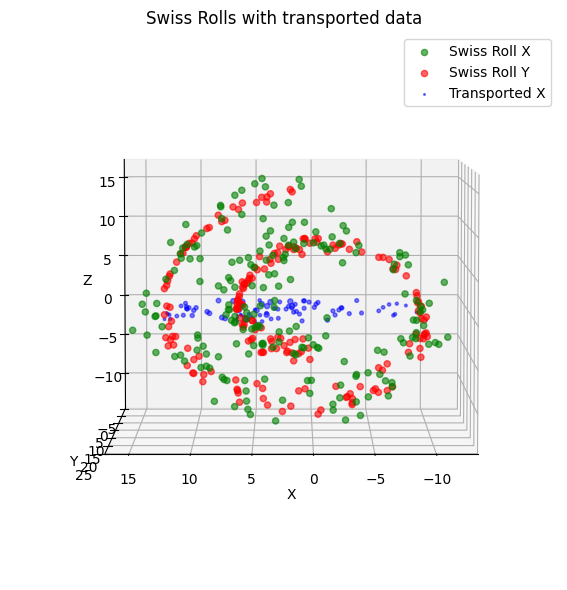

CPU times: user 29 μs, sys: 2 μs, total: 31 μs
Wall time: 61.5 μs

Entropic OT plan (reg=1.0)
Wasserstein distance (reg=1.0): 0.50
Chamfer distance (reg=1.0): 0.52
Dual distance (reg=1.0): 20.53


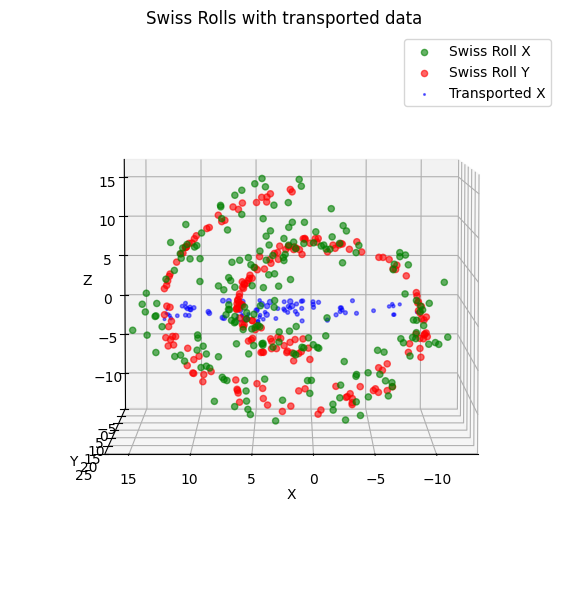

CPU times: user 35 μs, sys: 3 μs, total: 38 μs
Wall time: 76.5 μs

Entropic OT plan (reg=10.0)
Wasserstein distance (reg=10.0): 2.32
Chamfer distance (reg=10.0): 1.07
Dual distance (reg=10.0): 148.43


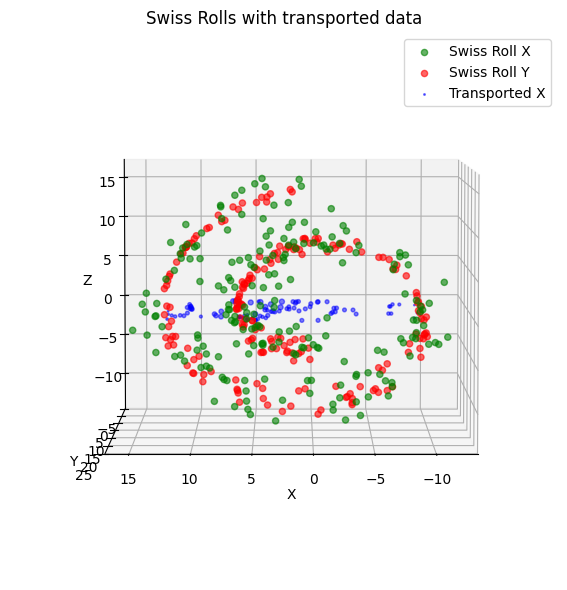

In [67]:
reg_list = [0.1, 1.0, 10.0]

for reg in reg_list:
    %time
    print(f"\nEntropic OT plan (reg={reg})")

    # Step 1: Define geometry
    geom = pointcloud.PointCloud(X, Y, epsilon=reg)

    # Step 2: Define the problem
    problem = linear_problem.LinearProblem(geom)

    # Step 3: Solve with Sinkhorn
    solver = sinkhorn.Sinkhorn()
    out = solver(problem)

    # Step 4: Transport using dual potentials
    entropic_map = out.to_dual_potentials()
    transported_X = entropic_map.transport(X)

    # Step 5: Compute distances
    ch_dist = chamfer_distance(transported_X, Y)
    dual_dist = entropic_map.distance(X, Y)
    wass_dist = sinkhorn_divergence(PointCloud, transported_X, Y, epsilon=0.1, 
                                    a=jnp.ones(len(transported_X)) / len(transported_X), b=jnp.ones(len(Y)) / len(Y))[0]
    print(f"Wasserstein distance (reg={reg}): {wass_dist:.2f}")
    print(f"Chamfer distance (reg={reg}): {ch_dist:.2f}")
    print(f"Dual distance (reg={reg}): {dual_dist:.2f}")

    # Step 7: Visualization
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='green', label='Swiss Roll X', alpha=0.6)
    ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], c='red', label='Swiss Roll Y', alpha=0.6)
    plt.scatter(transported_X[:, 0], transported_X[:, 1], transported_X[:, 2], c='blue', label='Transported X', alpha=0.5)
    
    ax.set_title('Swiss Rolls with transported data')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    
    ax.view_init(elev=5, azim=90)
    
    plt.tight_layout()
    plt.show()